<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/UCI_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv("heart_disease.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['sex']

,sex
0,1.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
298,1.0
299,1.0
300,1.0
301,0.0


In [7]:
X = df.drop('target', axis=1)
y = df['target']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled_train=scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)


In [9]:
(X_train)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,29.0,1.0,2.0,130.0,204.0,0.0,2.0,202.0,0.0,0.0,1.0,0.0,3.0
202,57.0,1.0,3.0,150.0,126.0,1.0,0.0,173.0,0.0,0.2,1.0,1.0,7.0
196,69.0,1.0,1.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,2.0,1.0,3.0
75,65.0,0.0,3.0,160.0,360.0,0.0,2.0,151.0,0.0,0.8,1.0,0.0,3.0
176,52.0,1.0,4.0,108.0,233.0,1.0,0.0,147.0,0.0,0.1,1.0,3.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,54.0,1.0,2.0,192.0,283.0,0.0,2.0,195.0,0.0,0.0,1.0,1.0,7.0
71,67.0,1.0,4.0,125.0,254.0,1.0,0.0,163.0,0.0,0.2,2.0,2.0,7.0
106,59.0,1.0,4.0,140.0,177.0,0.0,0.0,162.0,1.0,0.0,1.0,1.0,7.0
270,61.0,1.0,4.0,140.0,207.0,0.0,2.0,138.0,1.0,1.9,1.0,1.0,7.0


In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=13))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from keras.optimizers import Adam
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.0001),metrics=['accuracy'])

In [13]:
model.fit(X_scaled_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.6218 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5544 - loss: nan - val_accuracy: 0.5714 - val_loss: nan
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/ste

In [14]:
y_pred=model.predict(X_scaled_test)
y_pred

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]], dtype=float32)

In [15]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [16]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

In [17]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [18]:
print("X NaN:", X.isnull().sum().sum())
print("y NaN:", y.isnull().sum())

X NaN: 6
y NaN: 0


In [19]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [20]:
# 1. Create X and y again
X = df.drop('target', axis=1)
y = df['target']

# 2. Check
print("X NaN:", X.isnull().sum().sum())
print("y NaN:", y.isnull().sum())

X NaN: 0
y NaN: 0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
import numpy as np

print("Train NaN:", np.isnan(X_train).sum())
print("Test NaN:", np.isnan(X_test).sum())
from sklearn.metrics import accuracy_score

Train NaN: 0
Test NaN: 0


In [27]:
import numpy as np
import tensorflow as tf

# X and y
X = df.drop('target', axis=1)
y = df['target']

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check data
print("X_train NaN:", np.isnan(X_train).sum())
print("X_test NaN:", np.isnan(X_test).sum())

# ANN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Prediction
y_pred = model.predict(X_test)

print("NaN predictions:", np.isnan(y_pred).sum())
print(y_pred[:10])

X_train NaN: 0
X_test NaN: 0
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.5699 - loss: 0.7320 - val_accuracy: 0.4694 - val_loss: 0.7431
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6580 - loss: 0.6358 - val_accuracy: 0.5306 - val_loss: 0.6727
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7513 - loss: 0.5751 - val_accuracy: 0.6327 - val_loss: 0.6242
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8083 - loss: 0.5207 - val_accuracy: 0.7551 - val_loss: 0.5782
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8290 - loss: 0.4738 - val_accuracy: 0.7755 - val_loss: 0.5468
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8446 - loss: 0.4358 - val_accuracy: 0.7755 - val_loss: 0.5347
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8497 - loss: 0.4073 - val_accuracy: 0.7959 - val_loss: 0.5061
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8497 - loss: 0.3870 - v

In [28]:
from sklearn.metrics import accuracy_score

y_pred_class = (y_pred >= 0.5).astype(int).ravel()

acc = accuracy_score(y_test, y_pred_class)

print("Accuracy:", acc)

Accuracy: 0.8524590163934426


In [29]:
y_pred_prob = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [30]:
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()


In [31]:
for actual, predicted in zip(y_test.values[:10], y_pred[:10]):
    print("Actual:", actual, "Predicted:", predicted)

Actual: 0 Predicted: 0
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0


In [32]:
correct = (y_test.values == y_pred).sum()
total = len(y_test)

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", correct / total)

Correct: 52
Total: 61
Accuracy: 0.8524590163934426


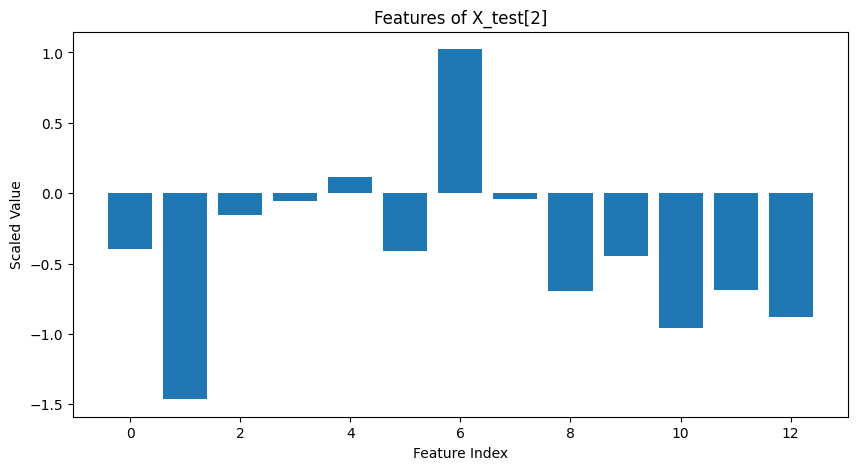

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(range(len(X_test[2])), X_test[2])
plt.xlabel('Feature Index')
plt.ylabel('Scaled Value')
plt.title('Features of X_test[2]')
plt.show()

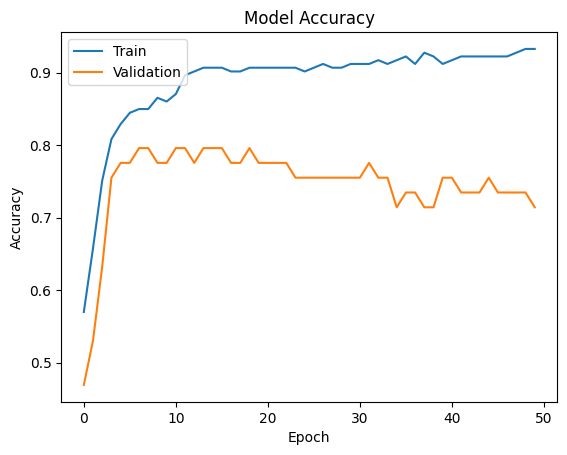

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
